In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)


In [8]:
url = "https://raw.githubusercontent.com/Giskard-AI/examples/main/datasets/WA_Fn-UseC_-Telco-Customer-Churn.csv"

df = pd.read_csv(url)

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [9]:
df.shape


(7043, 21)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [11]:
df["Churn"].value_counts()

,count
Churn,
No,5174
Yes,1869


In [12]:
df["Churn"].value_counts(normalize=True) * 100

,proportion
Churn,
No,73.463013
Yes,26.536987


In [14]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [15]:
df.duplicated().sum()

np.int64(0)

In [16]:
df["TotalCharges"].dtype

dtype('O')

In [17]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")


In [18]:
df["TotalCharges"].isnull().sum()

np.int64(11)

In [19]:
df = df.dropna(subset=["TotalCharges"])

In [20]:
df.shape

(7032, 21)

In [21]:
X = df.drop(["Churn", "customerID"], axis=1)
y = df["Churn"]

# Convert Yes/No target into 1/0
y = y.map({"Yes": 1, "No": 0})

X.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65


In [22]:
X = pd.get_dummies(X, drop_first=True)

X.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,False,True,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,True,False,False,True,False,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,True,False,False,True,False,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,True,False,False,False,True,False,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,False,False,False,True,False,False,...,False,False,False,False,False,False,True,False,True,False


In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (5625, 30)
Testing data: (1407, 30)


In [24]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaled training data:", X_train_scaled.shape)
print("Scaled testing data:", X_test_scaled.shape)

Scaled training data: (5625, 30)
Scaled testing data: (1407, 30)


In [25]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

print("Predictions:", y_pred[:10])

Predictions: [0 1 0 0 0 0 0 0 1 0]


In [26]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.8038379530916845

Confusion Matrix:
[[916 117]
 [159 215]]

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1033
           1       0.65      0.57      0.61       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407



In [27]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.7896233120113717

Confusion Matrix:
[[917 116]
 [180 194]]

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1033
           1       0.63      0.52      0.57       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407



In [28]:
model_balanced = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

model_balanced.fit(X_train_scaled, y_train)

y_pred_balanced = model_balanced.predict(X_test_scaled)

print("Balanced Logistic Regression Accuracy:",
      accuracy_score(y_test, y_pred_balanced))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_balanced))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_balanced))

Balanced Logistic Regression Accuracy: 0.7263681592039801

Confusion Matrix:
[[724 309]
 [ 76 298]]

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.70      0.79      1033
           1       0.49      0.80      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.79      0.73      0.74      1407



In [29]:
from sklearn.metrics import roc_auc_score

# Probability of class 1 (Churn)
y_prob = model.predict_proba(X_test_scaled)[:, 1]
y_prob_balanced = model_balanced.predict_proba(X_test_scaled)[:, 1]

print("Logistic Regression ROC-AUC:",
      roc_auc_score(y_test, y_prob))

print("Balanced Logistic Regression ROC-AUC:",
      roc_auc_score(y_test, y_prob_balanced))

Logistic Regression ROC-AUC: 0.8356727976766699
Balanced Logistic Regression ROC-AUC: 0.8349765233911922


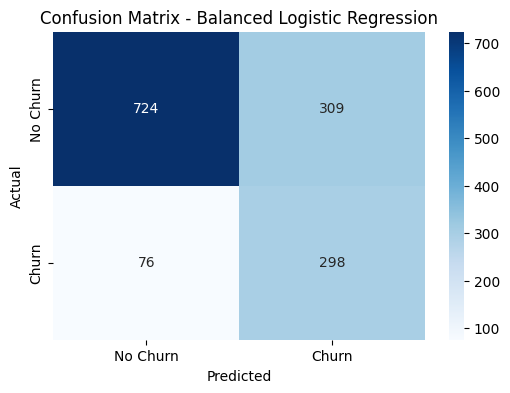

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_balanced)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Balanced Logistic Regression")
plt.show()

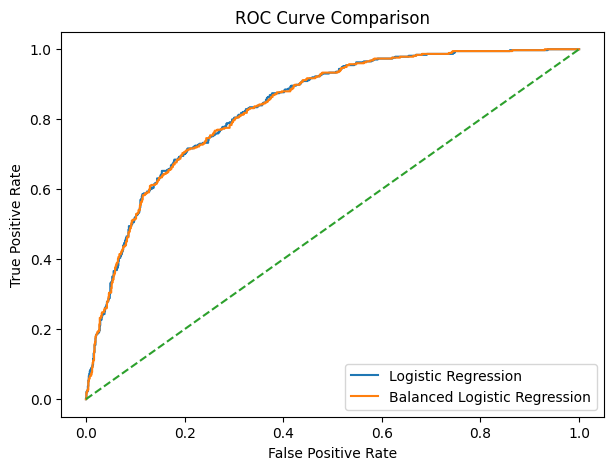

In [31]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob)
fpr_bal, tpr_bal, _ = roc_curve(y_test, y_prob_balanced)

plt.figure(figsize=(7,5))

plt.plot(fpr_lr, tpr_lr, label="Logistic Regression")
plt.plot(fpr_bal, tpr_bal, label="Balanced Logistic Regression")

plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

In [32]:
# Feature importance from Balanced Logistic Regression

feature_names = X.columns
coefficients = model_balanced.coef_[0]

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

feature_importance["Absolute_Coefficient"] = abs(
    feature_importance["Coefficient"]
)

feature_importance = feature_importance.sort_values(
    "Absolute_Coefficient",
    ascending=False
)

feature_importance.head(15)

,Feature,Coefficient,Absolute_Coefficient
1,tenure,-1.263854,1.263854
2,MonthlyCharges,-0.928682,0.928682
10,InternetService_Fiber optic,0.746144,0.746144
25,Contract_Two year,-0.638598,0.638598
3,TotalCharges,0.623279,0.623279
24,Contract_One year,-0.326693,0.326693
21,StreamingTV_Yes,0.259691,0.259691
23,StreamingMovies_Yes,0.252870,0.252870
9,MultipleLines_Yes,0.202763,0.202763
28,PaymentMethod_Electronic check,0.193697,0.193697


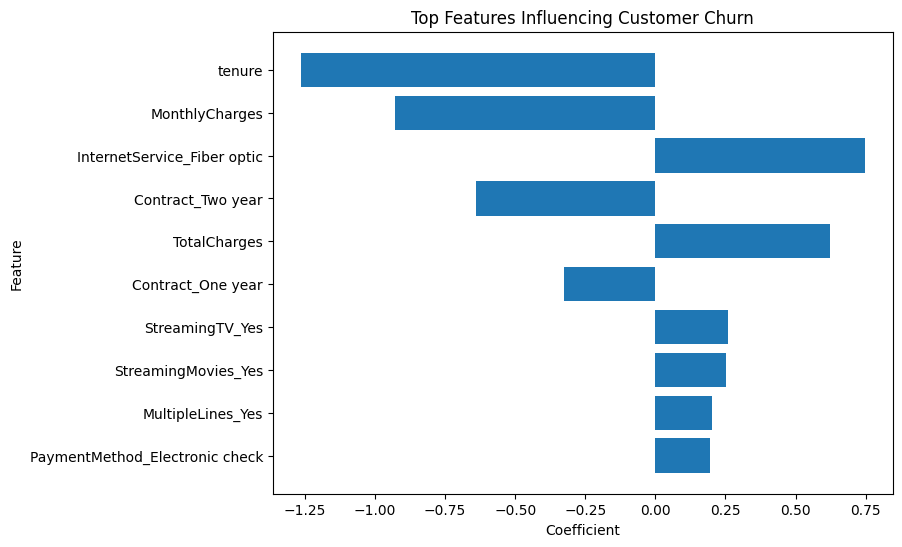

In [33]:
plt.figure(figsize=(8,6))

top_features = feature_importance.head(10)

plt.barh(
    top_features["Feature"],
    top_features["Coefficient"]
)

plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.title("Top Features Influencing Customer Churn")
plt.gca().invert_yaxis()

plt.show()

In [34]:
# Take one customer from the test data
sample_customer = X_test.iloc[[0]]

# Actual churn value
actual = y_test.iloc[0]

# Predict churn
prediction = model_balanced.predict(
    scaler.transform(sample_customer)
)[0]

# Churn probability
probability = model_balanced.predict_proba(
    scaler.transform(sample_customer)
)[0][1]

print("Actual Churn:", actual)
print("Predicted Churn:", prediction)
print("Churn Probability:", round(probability * 100, 2), "%")

Actual Churn: 0
Predicted Churn: 0
Churn Probability: 4.9 %


In [35]:
print("===== FINAL MODEL COMPARISON =====")

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred))
print("Balanced Logistic Regression Accuracy:",
      accuracy_score(y_test, y_pred_balanced))
print("Random Forest Accuracy:",
      accuracy_score(y_test, y_pred_rf))

print("\nROC-AUC Scores:")
print("Logistic Regression ROC-AUC:", roc_auc_score(y_test, y_prob))
print("Balanced Logistic Regression ROC-AUC:",
      roc_auc_score(y_test, y_prob_balanced))

===== FINAL MODEL COMPARISON =====
Logistic Regression Accuracy: 0.8038379530916845
Balanced Logistic Regression Accuracy: 0.7263681592039801
Random Forest Accuracy: 0.7896233120113717

ROC-AUC Scores:
Logistic Regression ROC-AUC: 0.8356727976766699
Balanced Logistic Regression ROC-AUC: 0.8349765233911922


In [36]:
import joblib

# Save the final model
joblib.dump(model, "customer_churn_model.pkl")

# Save the scaler
joblib.dump(scaler, "customer_churn_scaler.pkl")

print("Model and scaler saved successfully!")

Model and scaler saved successfully!


In [37]:
import joblib

# Load saved model and scaler
loaded_model = joblib.load("customer_churn_model.pkl")
loaded_scaler = joblib.load("customer_churn_scaler.pkl")

# Take one customer from test data
sample_customer = X_test.iloc[[0]]

# Scale the customer data
sample_scaled = loaded_scaler.transform(sample_customer)

# Predict
prediction = loaded_model.predict(sample_scaled)[0]
probability = loaded_model.predict_proba(sample_scaled)[0][1]

print("Predicted Churn:", prediction)
print("Churn Probability:", round(probability * 100, 2), "%")

Predicted Churn: 0
Churn Probability: 1.71 %


In [40]:
# Enter customer details

tenure = float(input("Enter tenure (months): "))
monthly_charges = float(input("Enter monthly charges: "))
total_charges = float(input("Enter total charges: "))

# Create input using the average values for other features
customer_input = X_test.iloc[[0]].copy()

customer_input["tenure"] = tenure
customer_input["MonthlyCharges"] = monthly_charges
customer_input["TotalCharges"] = total_charges

# Scale input
customer_scaled = loaded_scaler.transform(customer_input)

# Prediction
prediction = loaded_model.predict(customer_scaled)[0]
probability = loaded_model.predict_proba(customer_scaled)[0][1]

print("\n===== CHURN PREDICTION =====")

if prediction == 1:
    print("Prediction: Customer will CHURN")
else:
    print("Prediction: Customer will NOT CHURN")

print("Churn Probability:", round(probability * 100, 2), "%")

Enter tenure (months): 12
Enter monthly charges: 70
Enter total charges: 840

===== CHURN PREDICTION =====
Prediction: Customer will NOT CHURN
Churn Probability: 8.78 %


In [41]:
# Complete Customer Churn Prediction

import pandas as pd

print("===== ENTER CUSTOMER DETAILS =====")

# Numeric features
senior_citizen = int(input("Senior Citizen? (0 = No, 1 = Yes): "))
tenure = float(input("Tenure (months): "))
monthly_charges = float(input("Monthly Charges: "))
total_charges = float(input("Total Charges: "))

# Create a row with all features initially set to 0
customer_input = pd.DataFrame(0, index=[0], columns=X.columns)

# Set numeric values
customer_input["SeniorCitizen"] = senior_citizen
customer_input["tenure"] = tenure
customer_input["MonthlyCharges"] = monthly_charges
customer_input["TotalCharges"] = total_charges

# Gender
gender = input("Gender (Male/Female): ").strip().lower()
if gender == "male" and "gender_Male" in customer_input.columns:
    customer_input["gender_Male"] = 1

# Partner
if input("Has Partner? (Yes/No): ").strip().lower() == "yes":
    customer_input["Partner_Yes"] = 1

# Dependents
if input("Has Dependents? (Yes/No): ").strip().lower() == "yes":
    customer_input["Dependents_Yes"] = 1

# Phone Service
if input("Phone Service? (Yes/No): ").strip().lower() == "yes":
    customer_input["PhoneService_Yes"] = 1

# Multiple Lines
multiple_lines = input(
    "Multiple Lines (Yes/No/No phone service): "
).strip().lower()

if multiple_lines == "yes" and "MultipleLines_Yes" in customer_input.columns:
    customer_input["MultipleLines_Yes"] = 1
elif multiple_lines == "no phone service" and "MultipleLines_No phone service" in customer_input.columns:
    customer_input["MultipleLines_No phone service"] = 1

# Internet Service
internet = input(
    "Internet Service (DSL/Fiber optic/No): "
).strip().lower()

if internet == "fiber optic" and "InternetService_Fiber optic" in customer_input.columns:
    customer_input["InternetService_Fiber optic"] = 1
elif internet == "no" and "InternetService_No" in customer_input.columns:
    customer_input["InternetService_No"] = 1

# Contract
contract = input(
    "Contract (Month-to-month/One year/Two year): "
).strip().lower()

if contract == "one year" and "Contract_One year" in customer_input.columns:
    customer_input["Contract_One year"] = 1
elif contract == "two year" and "Contract_Two year" in customer_input.columns:
    customer_input["Contract_Two year"] = 1

# Paperless Billing
if input("Paperless Billing? (Yes/No): ").strip().lower() == "yes":
    customer_input["PaperlessBilling_Yes"] = 1

# Payment Method
payment = input(
    "Payment Method (Electronic check/Other): "
).strip().lower()

if payment == "electronic check" and "PaymentMethod_Electronic check" in customer_input.columns:
    customer_input["PaymentMethod_Electronic check"] = 1

# Scale and predict
customer_scaled = loaded_scaler.transform(customer_input)

prediction = loaded_model.predict(customer_scaled)[0]
probability = loaded_model.predict_proba(customer_scaled)[0][1]

print("\n===== CHURN PREDICTION =====")

if prediction == 1:
    print("Prediction: CUSTOMER WILL CHURN")
else:
    print("Prediction: CUSTOMER WILL NOT CHURN")

print("Churn Probability:", round(probability * 100, 2), "%")

===== ENTER CUSTOMER DETAILS =====
Senior Citizen? (0 = No, 1 = Yes): 1
Tenure (months): 11
Monthly Charges: 70
Total Charges: 840
Gender (Male/Female): 0
Has Partner? (Yes/No): 0
Has Dependents? (Yes/No): 1
Phone Service? (Yes/No): 0
Multiple Lines (Yes/No/No phone service): no
Internet Service (DSL/Fiber optic/No): no
Contract (Month-to-month/One year/Two year): two years
Paperless Billing? (Yes/No): no
Payment Method (Electronic check/Other): other

===== CHURN PREDICTION =====
Prediction: CUSTOMER WILL NOT CHURN
Churn Probability: 16.65 %
